In [29]:
import pandas as pd
df = pd.read_csv("../data/examples_DBAASP/descriptors_positive_staphylococcus.csv")

In [30]:
# normalizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df)
scaled_features = scaler.transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

<Axes: >

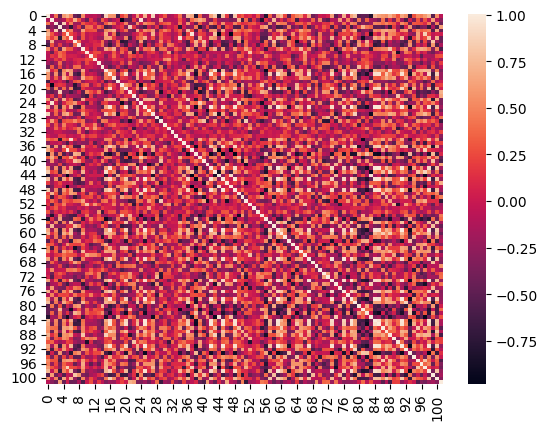

In [31]:
# variance matrix

import numpy as np
import seaborn as sns
cov_matrix = np.cov(scaled_features.T)
sns.heatmap(cov_matrix)

In [33]:
# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]

print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}")

TypeError: VarianceThreshold.__init__() got an unexpected keyword argument 'treshold'

In [34]:
# trash randomly one of the features with correlation > 0.9
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")


Features dropped: ['F2', 'F3', 'KF1', 'KF2', 'MSWHIM1', 'E1', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'ST1', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'VHSE1', 'VHSE2', 'VHSE3', 'VSTPV1', 'VSTPV3', 'Z1', 'Z2']
New shape: (721, 76)


In [37]:
# trash all features with "BLOSUM" in the name
to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")

Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (721, 66)


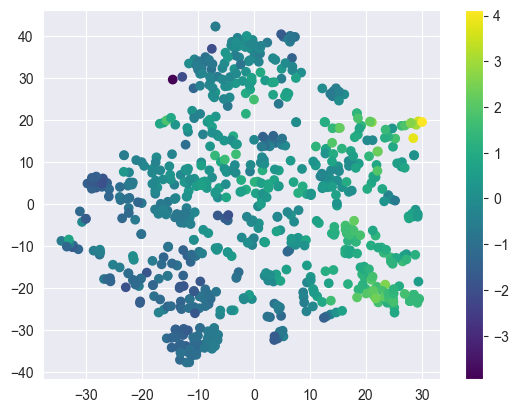

In [39]:
# TSNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(df_feat)

# gradient for the first feature
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df_feat.iloc[:, 0], cmap='viridis')
plt.colorbar()
plt.show()

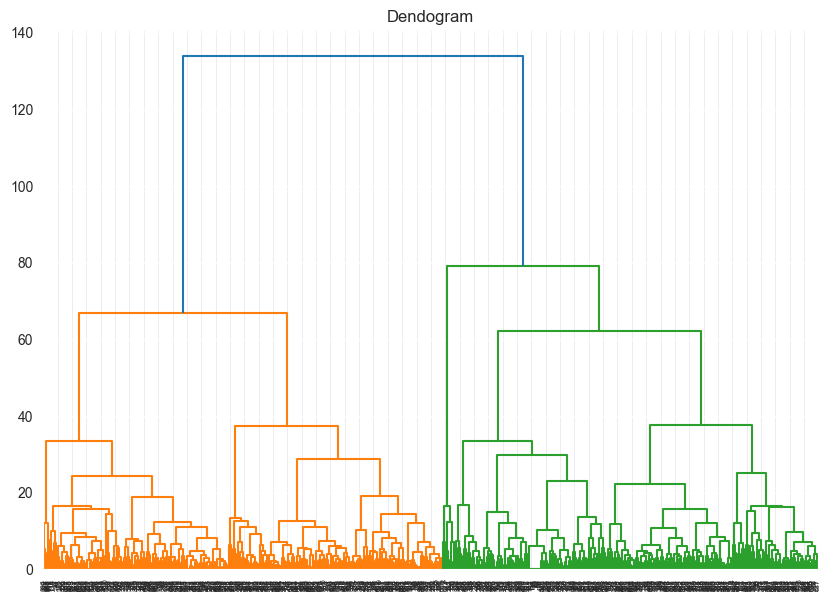

In [40]:
# dendrogram visualization - hierarchical clustering
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Dendogram")
dend = shc.dendrogram(shc.linkage(df, method='ward'))

plt.show()

In [41]:
# KMeans clustering

from sklearn import metrics
from sklearn.cluster import KMeans

silhouette_scores = []
for i in range(2, 100):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(df)
    score = metrics.silhouette_score(df, kmeans.labels_, metric='euclidean')
    silhouette_scores.append(score)
    print(f"Silhouette score for {i} clusters: {score}")


Silhouette score for 2 clusters: 0.35436842314687345
Silhouette score for 3 clusters: 0.2765021155193237
Silhouette score for 4 clusters: 0.19903881726813466
Silhouette score for 5 clusters: 0.1973412186532934
Silhouette score for 6 clusters: 0.20595764566163952
Silhouette score for 7 clusters: 0.19175492333519017
Silhouette score for 8 clusters: 0.194381626036041
Silhouette score for 9 clusters: 0.17049838532999187
Silhouette score for 10 clusters: 0.16970312534032878
Silhouette score for 11 clusters: 0.18394398306642876
Silhouette score for 12 clusters: 0.19287281001428563
Silhouette score for 13 clusters: 0.1923091276915913
Silhouette score for 14 clusters: 0.192935956881744
Silhouette score for 15 clusters: 0.1958692277017962
Silhouette score for 16 clusters: 0.18229483001180563
Silhouette score for 17 clusters: 0.18091021232792834
Silhouette score for 18 clusters: 0.17546914231804128
Silhouette score for 19 clusters: 0.17971253595802894
Silhouette score for 20 clusters: 0.17510526